# EDA and Feature Selection

This notebook walks through **Exploratory Data Analysis (EDA)** and **four feature selection methods** for a binary churn classification task.

The goal is to identify which features are most predictive of churn, compare methods, and produce a consolidated decision table.

---

### Workflow Overview

1. **Load data** — inspect shape, types, and class balance  
2. **EDA** — distributions, correlations, missing values  
3. **Feature selection**
* **Filter method** — ANOVA F-test and Correlation Matrix  
* **Wrapper method** — Recursive Feature Elimination (RFE)  
* **Embedded method (DT)** — Decision Tree feature importances  
* **Embedded method (RF)** — Random Forest feature importances  
4.  **Summary Comparison Table** — consolidated decision  

---
## 0. Imports & Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# Scikit-learn
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Color palette
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'churn=0': '#4C72B0', 'churn=1': '#DD8452'}
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

print('Setup complete.')

Setup complete.


---
## 1. Load Data

> **`features.py`** must be on your Python path.  
> `load_training_dataset()` should return a `pd.DataFrame` with at least columns `user_id`, `churn`, and one or more numeric feature columns.

In [2]:
from app.features import load_training_dataset

df = load_training_dataset()

X = df.drop(columns=['user_id', 'churn'])
y = df['churn']

print(f'Dataset shape : {df.shape}')
print(f'Features      : {list(X.columns)}')
print(f'Target balance:\n{y.value_counts(normalize=True).rename({0:"no churn",1:"churn"}).to_string()}')

Dataset shape : (300, 10)
Features      : ['account_age_days', 'activity_velocity', 'cart_frequency_ratio', 'total_spent', 'avg_items_per_cart', 'distinct_categories', 'expensive_ratio', 'bought_electronics']
Target balance:
churn
no churn    0.87
churn       0.13


---
## 2. Exploratory Data Analysis

Before any modelling we need to understand the data:

* **Data types & missing values** — unusable features should be caught early  
* **Distributions per class** — do features visually separate churned vs. retained users?  
* **Correlation heatmap** — highly correlated features are redundant; keep the best representative  
* **Class balance** — imbalance affects every downstream metric  

### 2.1 Dataset Overview

In [3]:
summary = pd.DataFrame({
    'dtype'  : X.dtypes,
    'missing': X.isnull().sum(),
    'missing_%': (X.isnull().mean() * 100).round(1),
    'mean'   : X.mean().round(3),
    'std'    : X.std().round(3),
    'min'    : X.min(),
    'max'    : X.max(),
})
display(summary)

,dtype,missing,missing_%,mean,std,min,max
account_age_days,int64,0,0.0,461.937,276.858,0.0,970.000000
activity_velocity,int64,0,0.0,0.157,2.918,-10.0,10.000000
cart_frequency_ratio,float64,0,0.0,0.039,0.061,0.0,0.411765
total_spent,float64,0,0.0,16739.691,11013.719,0.0,44658.130000
avg_items_per_cart,float64,0,0.0,7.259,2.448,0.0,15.500000
distinct_categories,int64,0,0.0,3.650,0.961,0.0,4.000000
expensive_ratio,float64,0,0.0,0.759,0.207,0.0,1.000000
bought_electronics,int64,0,0.0,0.913,0.282,0.0,1.000000


### 2.2 Target Class Balance

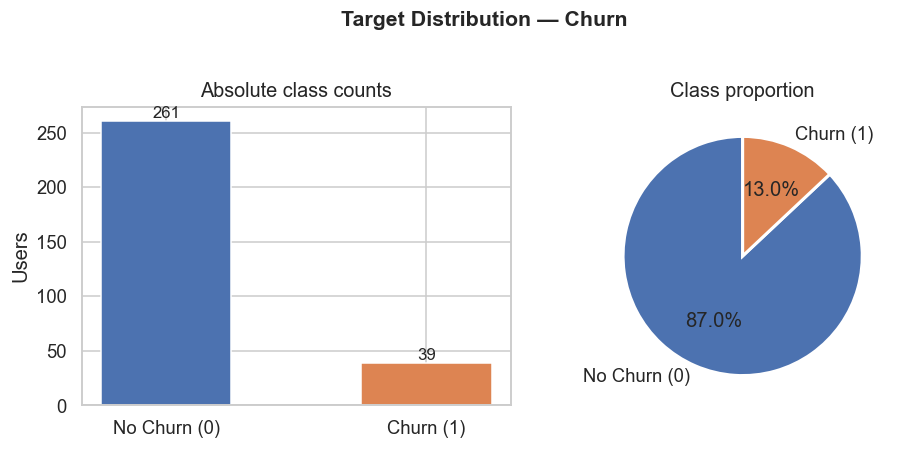

Churn rate: 13.0%
Class imbalance detected — consider SMOTE, class_weight="balanced", or adjusted thresholds.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

counts = y.value_counts().sort_index()
labels = ['No Churn (0)', 'Churn (1)']
colors = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Absolute class counts')
axes[0].set_ylabel('Users')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts) * 0.01, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Class proportion')

fig.suptitle('Target Distribution — Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

churn_rate = y.mean() * 100
print(f'Churn rate: {churn_rate:.1f}%')
if churn_rate < 20:
    print('Class imbalance detected — consider SMOTE, class_weight="balanced", or adjusted thresholds.')

### 2.3 Feature Distributions by Class

Overlapping KDE plots show whether each feature separates churned from retained users.  
Features with **well-separated distributions** are strong candidates to keep.

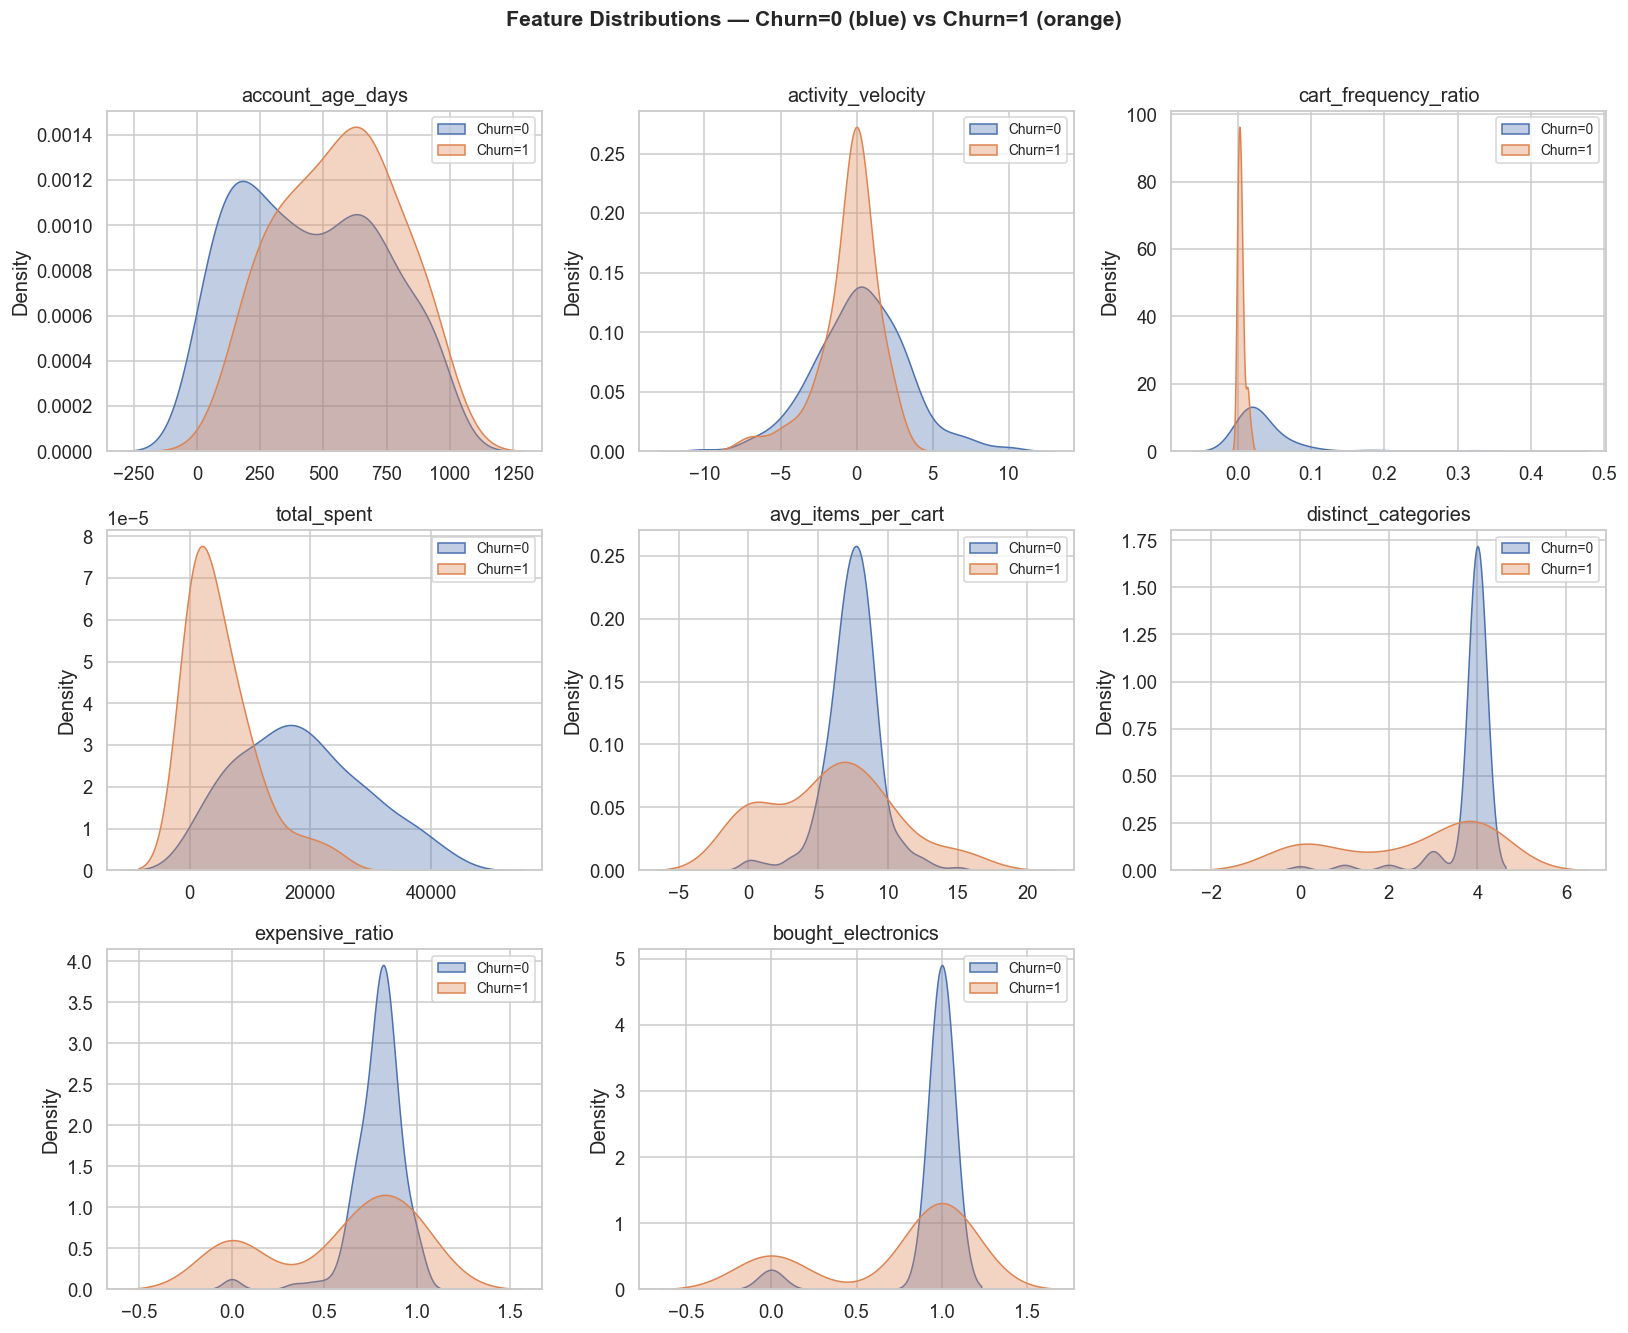

In [5]:
n_features = X.shape[1]
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    ax = axes[i]
    for cls, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        data = X.loc[y == cls, col].dropna()
        sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.35,
                    label=f'Churn={cls}')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=9)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — Churn=0 (blue) vs Churn=1 (orange)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Feature Selection 
## Method 1: Filter 
### - ANOVA F-test

**How it works:**  
Each feature is scored independently using the ANOVA F-statistic.       
A high F-score means the feature's mean differs significantly between classes.  


In [6]:
K = min(5, X.shape[1])

skb = SelectKBest(f_classif, k=K).fit(X, y)

filter_df = pd.DataFrame({
    'feature'     : X.columns,
    'f_score'     : skb.scores_,
    'p_value'     : skb.pvalues_,
    'selected'    : skb.get_support()
}).sort_values('f_score', ascending=False).reset_index(drop=True)

filter_df['filter_rank'] = filter_df.index + 1

display(filter_df.style.bar(subset=['f_score'], color='#4C72B0', vmin=0)
                        .format({'f_score': '{:.2f}', 'p_value': '{:.4f}'})
                        .highlight_between(subset=['selected'], left=True, right=True,
                                           props='background-color:#d4edda'))

,feature,f_score,p_value,selected,filter_rank
0,distinct_categories,83.77,0.0000,True,1
1,total_spent,57.40,0.0000,True,2
2,expensive_ratio,36.72,0.0000,True,3
3,bought_electronics,23.14,0.0000,True,4
4,avg_items_per_cart,14.84,0.0001,True,5
5,cart_frequency_ratio,14.46,0.0002,False,6
6,account_age_days,5.75,0.0171,False,7
7,activity_velocity,2.19,0.1398,False,8


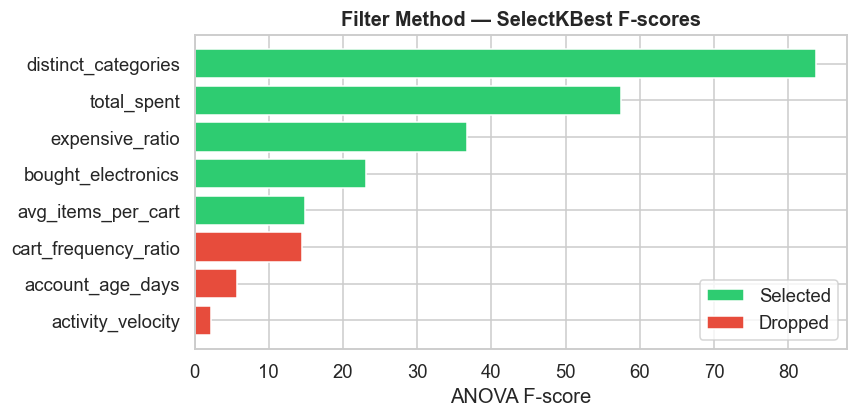

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    filter_df['feature'][::-1],
    filter_df['f_score'][::-1],
    color=['#2ecc71' if s else '#e74c3c' for s in filter_df['selected'][::-1]],
    edgecolor='white'
)
ax.set_xlabel('ANOVA F-score')
ax.set_title('Filter Method — SelectKBest F-scores', fontweight='bold')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='Selected'),
    Patch(facecolor='#e74c3c', label='Dropped')
], loc='lower right')

plt.tight_layout()
plt.show()

### - Correlation Matrix

Pearson correlation among all features.  
Pairs with **|r| > 0.8** are nearly redundant — keeping one of them is usually enough.

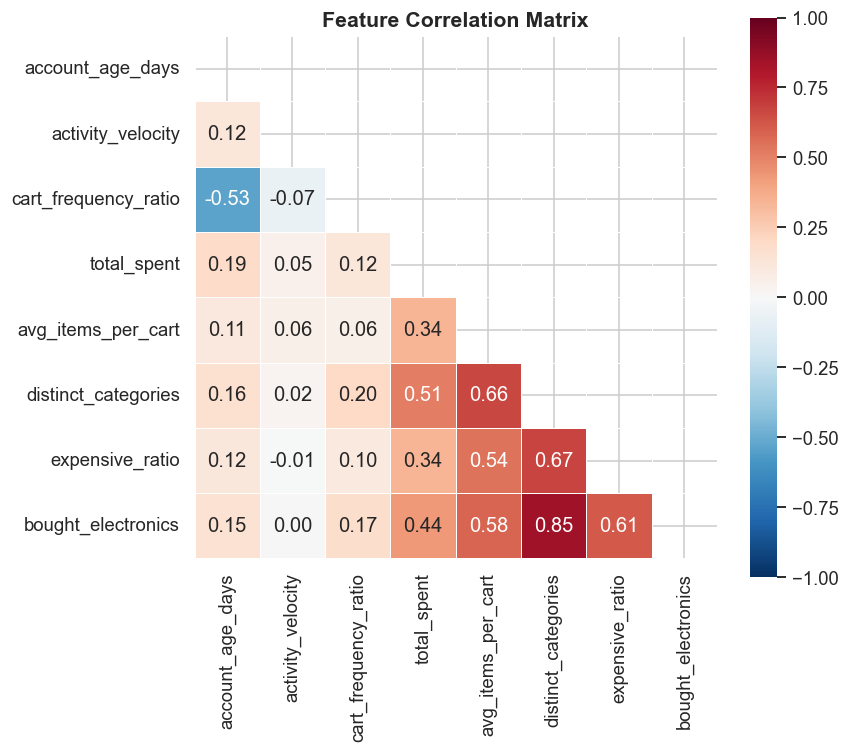

Highly correlated pairs (|r| > 0.8):


,feature_a,feature_b,correlation
0,bought_electronics,distinct_categories,0.850681


In [8]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(max(6, n_features), max(5, n_features - 1)))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    square=True, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = (
    corr.abs()
    .where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .loc[lambda s: s > 0.8]
)
if not high_corr.empty:
    print('Highly correlated pairs (|r| > 0.8):')
    display(high_corr.rename('correlation').reset_index().rename(columns={'level_0':'feature_a','level_1':'feature_b'}))
else:
    print('No feature pairs with |r| > 0.8 detected.')

---
## Method 2: Wrapper (RFE with Logistic Regression)

**How it works:**  
RFE repeatedly trains a Logistic Regression, ranks features by the absolute value of their coefficients, and removes the weakest one. It continues until only `n_features_to_select` remain.  


In [ ]:
pipe_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(LogisticRegression(max_iter=1000, random_state=42),
                n_features_to_select=K))
])
pipe_rfe.fit(X, y)

rfe_step = pipe_rfe.named_steps['rfe']

rfe_df = pd.DataFrame({
    'feature'     : X.columns,
    'rfe_rank'    : rfe_step.ranking_,  
    'rfe_selected': rfe_step.support_
}).sort_values('rfe_rank').reset_index(drop=True)

display(rfe_df.style.apply(
    lambda row: ['background-color: #d4edda' if row['rfe_selected'] else '' for _ in row],
    axis=1
))

,feature,rfe_rank,rfe_selected
0,account_age_days,1,True
1,activity_velocity,1,True
2,cart_frequency_ratio,1,True
3,total_spent,1,True
4,distinct_categories,1,True
5,bought_electronics,2,False
6,avg_items_per_cart,3,False
7,expensive_ratio,4,False


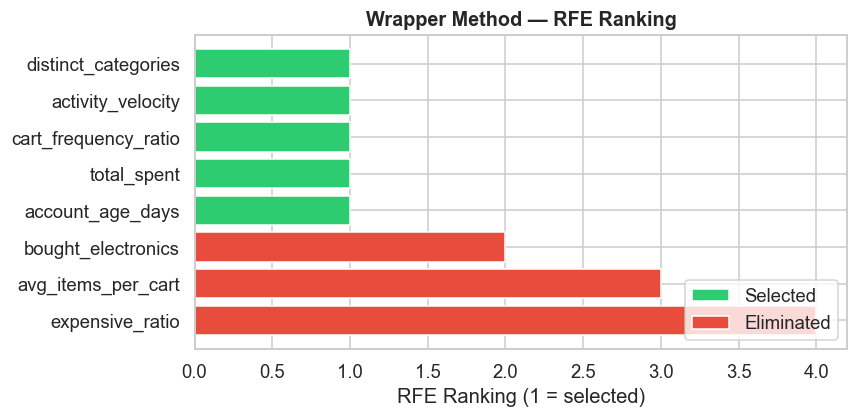

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sorted_rfe = rfe_df.sort_values('rfe_rank', ascending=False)
ax.barh(
    sorted_rfe['feature'],
    sorted_rfe['rfe_rank'],
    color=['#2ecc71' if s else '#e74c3c' for s in sorted_rfe['rfe_selected']],
    edgecolor='white'
)
ax.set_xlabel('RFE Ranking (1 = selected)')
ax.set_title('Wrapper Method — RFE Ranking', fontweight='bold')
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='Selected'),
    Patch(facecolor='#e74c3c', label='Eliminated')
], loc='lower right')
plt.tight_layout()
plt.show()

---
##  Method 3: Embedded (Decision Tree)

**How it works:**  
A Decision Tree assigns importance to each feature as the total **reduction in Gini impurity** caused by splits on that feature, weighted by the number of samples reaching each node.  


In [11]:
dt = DecisionTreeClassifier(random_state=42).fit(X, y)

dt_df = pd.DataFrame({
    'feature'       : X.columns,
    'dt_importance' : dt.feature_importances_
}).sort_values('dt_importance', ascending=False).reset_index(drop=True)

dt_df['dt_rank'] = dt_df.index + 1
display(dt_df)

,feature,dt_importance,dt_rank
0,cart_frequency_ratio,0.566018,1
1,total_spent,0.105205,2
2,account_age_days,0.096916,3
3,avg_items_per_cart,0.085891,4
4,expensive_ratio,0.049184,5
5,activity_velocity,0.045209,6
6,distinct_categories,0.036841,7
7,bought_electronics,0.014736,8


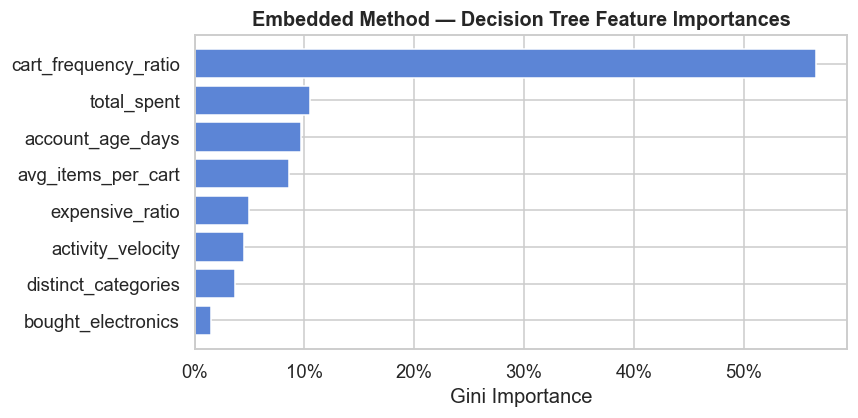

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sorted_dt = dt_df.sort_values('dt_importance')
ax.barh(
    sorted_dt['feature'],
    sorted_dt['dt_importance'],
    color='#5c85d6',
    edgecolor='white'
)
ax.set_xlabel('Gini Importance')
ax.set_title('Embedded Method — Decision Tree Feature Importances', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## Method 4: Random Forest

**How it works:**  
Random Forest trains 100+ trees, each on a bootstrap sample and a random feature subset. Importances are **averaged across all trees**, which smooths the variance caused by any single unlucky split.  


In [13]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X, y)

rf_df = pd.DataFrame({
    'feature'       : X.columns,
    'rf_importance' : rf.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)

rf_df['rf_rank'] = rf_df.index + 1
display(rf_df)

,feature,rf_importance,rf_rank
0,cart_frequency_ratio,0.290646,1
1,total_spent,0.167721,2
2,account_age_days,0.155751,3
3,avg_items_per_cart,0.131719,4
4,expensive_ratio,0.102147,5
5,distinct_categories,0.073062,6
6,activity_velocity,0.059626,7
7,bought_electronics,0.019328,8


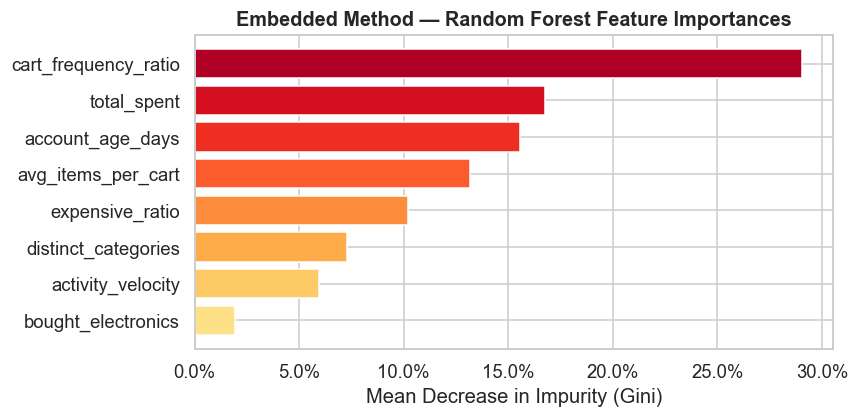

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sorted_rf = rf_df.sort_values('rf_importance')

# Gradient colour by rank
n = len(sorted_rf)
palette = plt.cm.YlOrRd(np.linspace(0.2, 0.9, n))

ax.barh(
    sorted_rf['feature'],
    sorted_rf['rf_importance'],
    color=palette,
    edgecolor='white'
)
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Embedded Method — Random Forest Feature Importances', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## 4. Feature Selection — Summary Comparison

After running all four methods we produce a **consolidated comparison table**.  
This forces a synthesised, cross-method view and makes the final decision explicit and auditable.

**Decision rules:**

| Signal | Decision |
|---|---|
| Top-K in ≥ 3 methods | ✅ **Keep** |
| Top-K in 2 methods (borderline) | ⚠️ **Optional** — test with and without |
| Top-K in 0–1 methods | ❌ **Drop**  |


In [ ]:
# ── Build the comparison DataFrame ───────────────────────────────────────────
comparison = (
    pd.DataFrame({'feature': X.columns})
    .merge(filter_df[['feature','filter_rank','f_score']], on='feature')
    .merge(rfe_df[['feature','rfe_rank','rfe_selected']], on='feature')
    .merge(dt_df[['feature','dt_rank','dt_importance']], on='feature')
    .merge(rf_df[['feature','rf_rank','rf_importance']], on='feature')
)

# ── Score: count how many methods put the feature in the top-K ───────────────
comparison['in_filter_topK']  = (comparison['filter_rank']  <= K).astype(int)
comparison['in_rfe_topK']     = comparison['rfe_selected'].astype(int)
comparison['in_dt_topK']      = (comparison['dt_rank']      <= K).astype(int)
comparison['in_rf_topK']      = (comparison['rf_rank']      <= K).astype(int)
comparison['method_count']    = (comparison[['in_filter_topK','in_rfe_topK',
                                              'in_dt_topK','in_rf_topK']].sum(axis=1))

# ── Final decision ────────────────────────────────────────────────────────────
def decide(row):
    if row['method_count'] >= 3:
        return 'Keep'
    elif row['method_count'] == 2:
        return 'Optional'
    else:
        return 'Drop'

comparison['decision'] = comparison.apply(decide, axis=1)

# ── Display ───────────────────────────────────────────────────────────────────
display_cols = ['feature', 'filter_rank', 'rfe_selected', 'dt_rank', 'rf_rank', 'method_count', 'decision']

def colour_decision(val):
    if 'Keep'     in str(val): return 'background-color: #d4edda; font-weight:bold'
    if 'Optional' in str(val): return 'background-color: #fff3cd; font-weight:bold'
    if 'Drop'     in str(val): return 'background-color: #f8d7da; font-weight:bold'
    return ''

styled = (
    comparison[display_cols]
    .sort_values('rf_rank')
    .style
    .map(colour_decision, subset=['decision'])  
    .bar(subset=['method_count'], vmin=0, vmax=4, color='#84b6f4')
)
display(styled)

print('\n--- Selected features ---')
selected = comparison.loc[comparison['decision'] == 'Keep', 'feature'].tolist()
optional = comparison.loc[comparison['decision'] == 'Optional', 'feature'].tolist()

print(f'Keep     : {selected}')
print(f'Optional : {optional}')

,feature,filter_rank,rfe_selected,dt_rank,rf_rank,method_count,decision
2,cart_frequency_ratio,6,True,1,1,3,Keep
3,total_spent,2,True,2,2,4,Keep
0,account_age_days,7,True,3,3,3,Keep
4,avg_items_per_cart,5,False,4,4,3,Keep
6,expensive_ratio,3,False,5,5,3,Keep
5,distinct_categories,1,True,7,6,2,Optional
1,activity_velocity,8,True,6,7,1,Drop
7,bought_electronics,4,False,8,8,1,Drop



--- Selected features ---
Keep     : ['account_age_days', 'cart_frequency_ratio', 'total_spent', 'avg_items_per_cart', 'expensive_ratio']
Optional : ['distinct_categories']


### 4.1 Cross-method Rank Comparison Chart

Visualise where each method agrees or disagrees on feature ranks.  
Features whose lines stay flat (consistent across methods) are the safest choices.

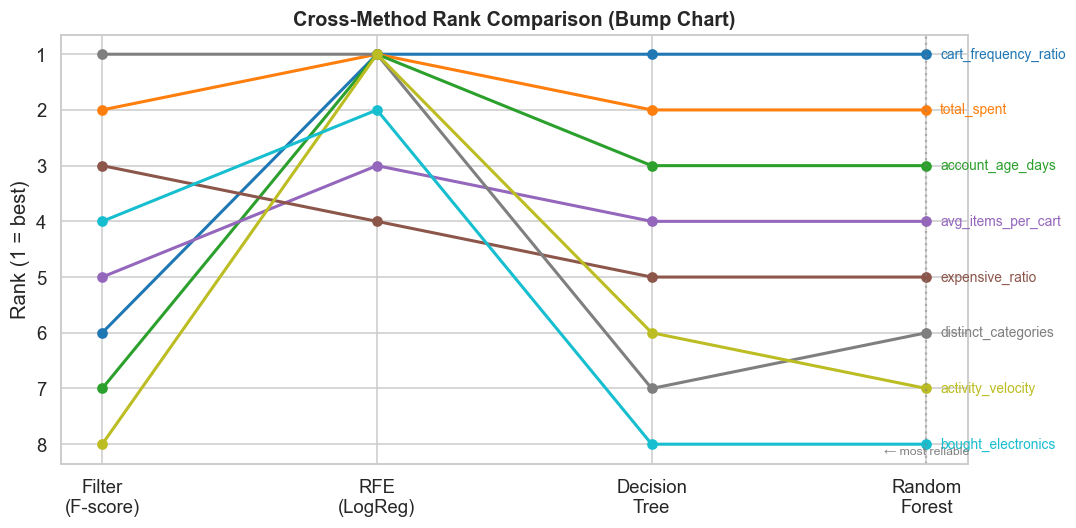

In [ ]:
rank_cols = ['filter_rank', 'rfe_rank', 'dt_rank', 'rf_rank']
method_labels = ['Filter\n(F-score)', 'RFE\n(LogReg)', 'Decision\nTree', 'Random\nForest']

fig, ax = plt.subplots(figsize=(10, 5))

n_feat = len(comparison)
palette_bump = plt.cm.tab10(np.linspace(0, 1, n_feat))

for i, (_, row) in enumerate(comparison.sort_values('rf_rank').iterrows()):
    ranks = row[rank_cols].values.astype(float)
    ax.plot(range(4), ranks, marker='o', linewidth=2,
            color=palette_bump[i], label=row['feature'])
    ax.text(3.05, ranks[-1], row['feature'], va='center', fontsize=9,
            color=palette_bump[i])

ax.set_xticks(range(4))
ax.set_xticklabels(method_labels)
ax.set_ylabel('Rank (1 = best)')
ax.invert_yaxis()   
ax.set_title('Cross-Method Rank Comparison (Bump Chart)', fontweight='bold')
ax.axvline(x=3, color='grey', linestyle=':', alpha=0.5)
ax.text(3, ax.get_ylim()[0] * 0.98, '← most reliable', ha='center',
        fontsize=8, color='grey')
plt.tight_layout()
plt.show()

---
## 5. Validation with Cross-Validation  

We use 5-fold stratified cross-validation with Logistic Regression on three feature sets:

* **Keep only** — the safest set  
* **Keep + Optional** — includes borderline features  
* **All features** — baseline  

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

keep_optional = selected + optional
feature_sets = {
    'Keep only'         : selected,
    'Keep + Optional'   : keep_optional,
    'All features'      : list(X.columns)
}

results = []
for label, feats in feature_sets.items():
    if not feats:
        continue
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)) 
    ])
    cv_res = cross_validate(pipe, X[feats], y, cv=cv, scoring=scoring)
    row = {'Feature Set': label, '# Features': len(feats)}
    for metric in scoring:
        scores = cv_res[f'test_{metric}']
        row[metric.capitalize()] = f'{scores.mean():.3f} ± {scores.std():.3f}'
    results.append(row)

cv_table = pd.DataFrame(results)
display(cv_table.style.set_caption('5-Fold Cross-Validation — Logistic Regression'))


,Feature Set,# Features,Accuracy,Precision,Recall,F1
0,Keep only,5,0.800 ± 0.035,0.380 ± 0.044,0.839 ± 0.163,0.520 ± 0.065
1,Keep + Optional,6,0.810 ± 0.017,0.374 ± 0.050,0.782 ± 0.265,0.498 ± 0.113
2,All features,8,0.843 ± 0.025,0.452 ± 0.036,0.868 ± 0.120,0.590 ± 0.039


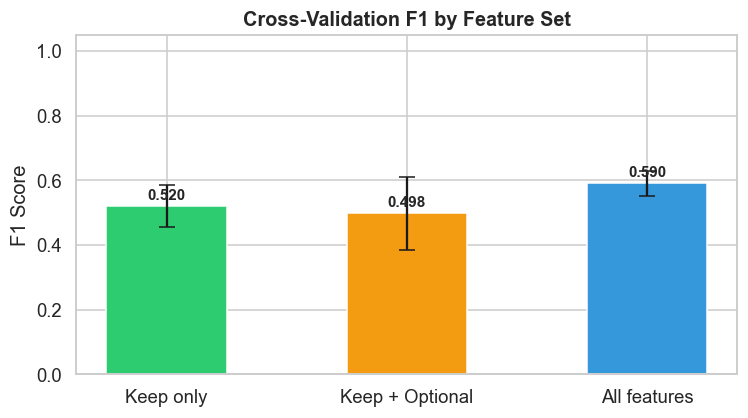

In [ ]:
# F1 comparison bar chart 
f1_means, f1_stds, labels_cv = [], [], []

keep_optional = selected + optional
feature_sets = {
    'Keep only'         : selected,
    'Keep + Optional'   : keep_optional,
    'All features'      : list(X.columns)
}

for label, feats in feature_sets.items():
    if not feats:
        print(f"Warning: '{label}' feature list is empty! Skipping.")
        continue
        
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        # Added class_weight='balanced' here to ensure fair logistic regression evaluation
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])
    
    cv_res = cross_validate(pipe, X[feats], y, cv=cv, scoring=['f1'])
    f1_means.append(cv_res['test_f1'].mean())
    f1_stds.append(cv_res['test_f1'].std())
    labels_cv.append(label)

# Plotting
fig, ax = plt.subplots(figsize=(7, 4))
colors_cv = ['#2ecc71', '#f39c12', '#3498db']
bars = ax.bar(labels_cv, f1_means, yerr=f1_stds, capsize=5,
              color=colors_cv, edgecolor='white', width=0.5)
              
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Cross-Validation F1 by Feature Set', fontweight='bold')

for bar, mean in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
            
plt.tight_layout()
plt.show()

---
## 6. Final Feature Set Summary

Based on the cross-method comparison and CV validation, the recommended final feature set is:

In [19]:
print('=' * 40)
print('FINAL FEATURE SET RECOMMENDATION')
print('=' * 40)
print(f'\n✅ Keep (unanimous / strong agreement):')
for f in selected:
    print(f'   • {f}')

if optional:
    print(f'\n⚠️  Optional (test with / without):')
    for f in optional:
        print(f'   • {f}')

dropped = comparison.loc[comparison['decision'] == 'Drop', 'feature'].tolist()
if dropped:
    print(f'\n❌ Drop (low importance across methods):')
    for f in dropped:
        print(f'   • {f}')



FINAL FEATURE SET RECOMMENDATION

✅ Keep (unanimous / strong agreement):
   • account_age_days
   • cart_frequency_ratio
   • total_spent
   • avg_items_per_cart
   • expensive_ratio

⚠️  Optional (test with / without):
   • distinct_categories

❌ Drop (low importance across methods):
   • activity_velocity
   • bought_electronics
